# Temporal and Seasonal Air Quality Analysis

## Objective

Air pollution is not constant throughout the year. Weather conditions, agricultural burning, industrial activity, and seasonal factors influence pollutant accumulation and dispersion.

This notebook investigates:

* Long-term AQI trends (2015–2020)
* Year-over-year AQI changes
* Monthly pollution patterns
* Seasonal air quality variations
* Impact of COVID-19 restrictions on AQI

The goal is to understand how air quality evolves over time and identify recurring seasonal patterns.


## Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## Load Dataset

In [ ]:
df = pd.read_csv("cleaned_aqi.csv")

## Temporal Feature Engineering

The Date column is converted into multiple time-based features:

- Year
- Month
- Season

These features enable trend and seasonal analysis.

In [5]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year

df['Month'] = df['Date'].dt.month

df['Week'] = df['Date'].dt.isocalendar().week

## Season Column 

In [ ]:
def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Summer"

    elif month in [6, 7, 8, 9]:
        return "Monsoon"

    else:
        return "Post-Monsoon"

df['Season'] = df['Month'].apply(get_season)

In [5]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket,Year,Month,Week,Season
0,Ahmedabad,2015-01-29,83.13,NaN,6.93,28.71,33.72,NaN,6.93,49.52,59.76,0.02,0.0,209.0,Poor,2015,1,5,Winter
1,Ahmedabad,2015-01-30,79.84,NaN,13.85,28.68,41.08,NaN,13.85,48.49,97.07,0.04,0.0,328.0,Very Poor,2015,1,5,Winter
2,Ahmedabad,2015-02-04,80.65,NaN,2.37,22.83,24.00,NaN,2.37,25.73,47.30,0.00,0.0,294.0,Poor,2015,2,6,Winter
3,Ahmedabad,2015-02-05,58.36,NaN,2.60,21.39,23.31,NaN,2.60,32.66,53.54,0.00,0.0,149.0,Moderate,2015,2,6,Winter
4,Ahmedabad,2015-02-06,79.29,NaN,1.16,26.94,26.83,NaN,1.16,67.41,59.30,0.00,0.0,190.0,Moderate,2015,2,6,Winter


## Annual AQI Trend Analysis

Average AQI is calculated for each year to evaluate whether air quality improved or deteriorated over the study period.

This analysis helps identify long-term environmental trends.

In [7]:
yearly_aqi = (
    df.groupby('Year')['AQI']
      .mean()
      .reset_index()
)

yearly_aqi

,Year,AQI
0,2015,199.385915
1,2016,187.785374
2,2017,171.017323
3,2018,159.217675
4,2019,143.205495
5,2020,110.934378


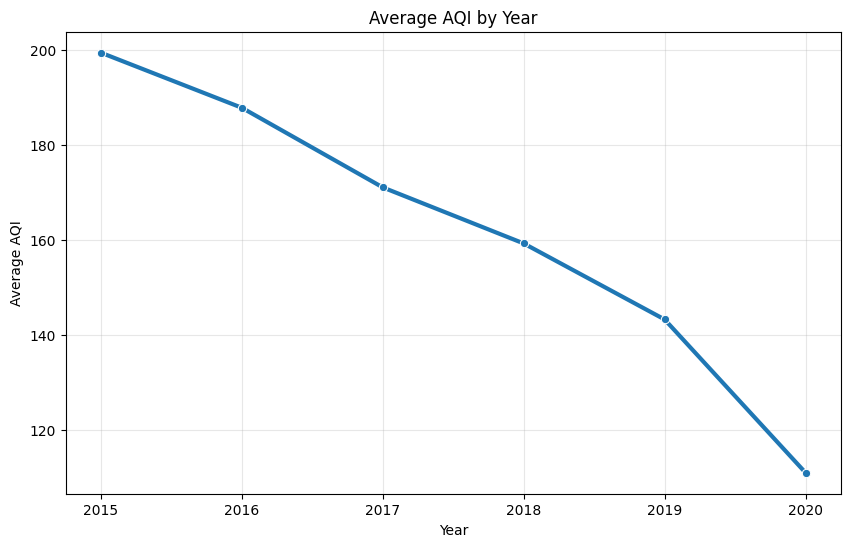

In [8]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=yearly_aqi,
    x='Year',
    y='AQI',
    marker='o',
    linewidth=3
)

plt.title('Average AQI by Year')
plt.ylabel('Average AQI')

plt.grid(alpha=0.3)

plt.show()

### Key Observation

The annual trend highlights how average pollution levels evolved between 2015 and 2020.

A declining trend suggests improving air quality, while an increasing trend indicates worsening pollution conditions.

## Year-over-Year Change Analysis

Year-over-year percentage change quantifies the rate at which AQI changes from one year to the next.

This helps identify years with significant improvements or deteriorations in air quality.


In [ ]:
yearly_aqi['YoY_Change_%'] = (
    yearly_aqi['AQI']
      .pct_change()
      .mul(100)
      .round(2)
)

yearly_aqi

,Year,AQI,YoY_Change_%
0,2015,199.385915,NaN
1,2016,187.785374,-5.82
2,2017,171.017323,-8.93
3,2018,159.217675,-6.90
4,2019,143.205495,-10.06
5,2020,110.934378,-22.53


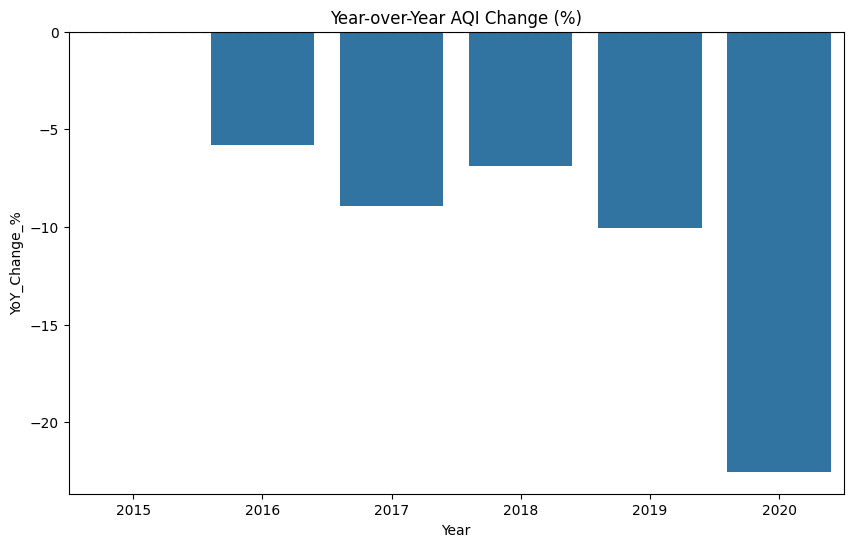

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=yearly_aqi,
    x='Year',
    y='YoY_Change_%'
)

plt.axhline(
    0,
    color='black',
    linestyle='--'
)

plt.title('Year-over-Year AQI Change (%)')

plt.show()

In [ ]:
aqi_2015 = yearly_aqi.loc[
    yearly_aqi['Year']==2015,
    'AQI'
].iloc[0]

aqi_2020 = yearly_aqi.loc[
    yearly_aqi['Year']==2020,
    'AQI'
].iloc[0]

overall_change = (
    (aqi_2020-aqi_2015)
    /aqi_2015
)*100

print(
    f"Overall AQI Change: {overall_change:.2f}%"
)

Overall AQI Change: -44.36%


## Monthly AQI Trend Analysis

Monthly averages are analyzed to identify recurring pollution cycles.

Environmental factors such as winter inversions, monsoon rainfall, and crop residue burning often create predictable monthly patterns.

In [ ]:
monthly_aqi = (
    df.groupby('Month')['AQI']
      .mean()
      .reset_index()
)

monthly_aqi

,Month,AQI
0,1,213.392460
1,2,183.076238
2,3,148.599208
3,4,134.193634
4,5,132.391358
5,6,115.302155
6,7,105.053532
7,8,106.459475
8,9,108.634006
9,10,167.040592


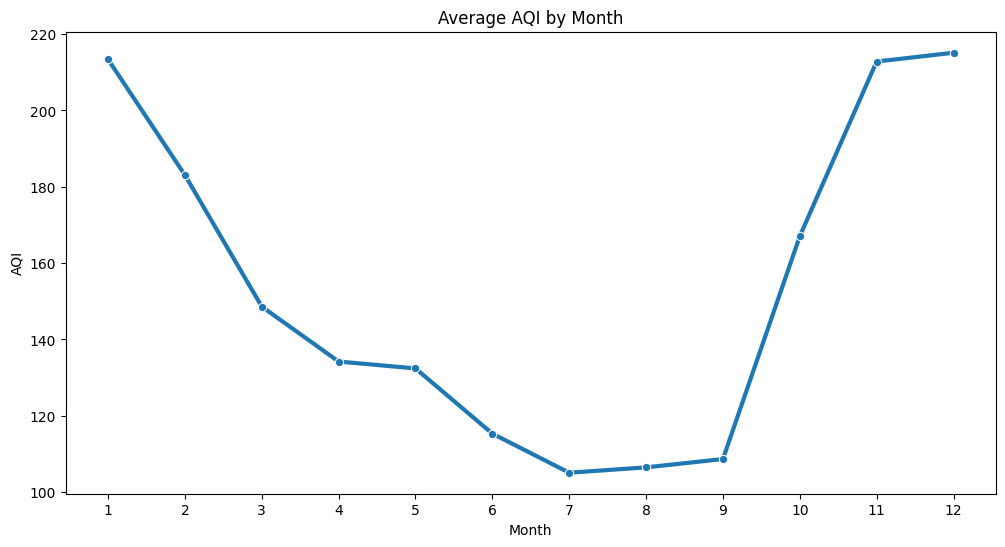

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_aqi,
    x='Month',
    y='AQI',
    marker='o',
    linewidth=3
)

plt.xticks(range(1,13))

plt.title('Average AQI by Month')

plt.show()

In [2]:
month_year = (
    df.pivot_table(
        values='AQI',
        index='Month',
        columns='Year',
        aggfunc='mean'
    )
)

NameError: name 'df' is not defined

## Month-Year AQI Heatmap

A heatmap provides a compact visualization of AQI levels across both months and years.

Darker regions indicate periods of elevated pollution and help identify recurring seasonal trends.

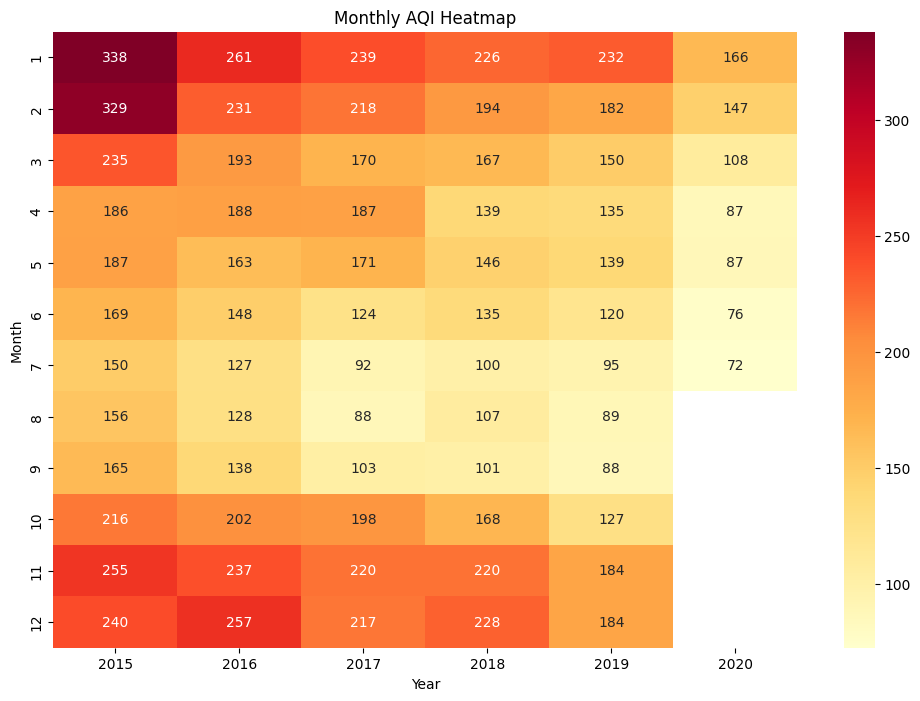

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    month_year,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd'
)

plt.title('Monthly AQI Heatmap')

plt.show()

## Seasonal Pollution Comparison

Months are grouped into four seasons:

- Winter
- Summer
- Monsoon
- Post-Monsoon

Comparing average AQI across seasons helps identify periods of greatest environmental risk.

In [ ]:
seasonal_aqi = (
    df.groupby('Season')['AQI']
      .mean()
      .sort_values(ascending=False)
)

seasonal_aqi

Season
Winter          203.861950
Post-Monsoon    190.023497
Summer          138.266045
Monsoon         109.312902
Name: AQI, dtype: float64

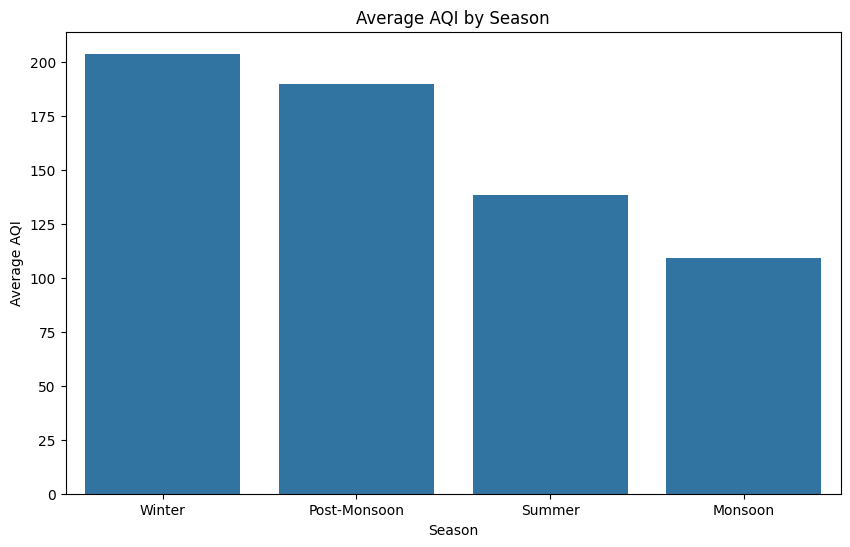

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=seasonal_aqi.index,
    y=seasonal_aqi.values
)

plt.title('Average AQI by Season')

plt.ylabel('Average AQI')

plt.show()

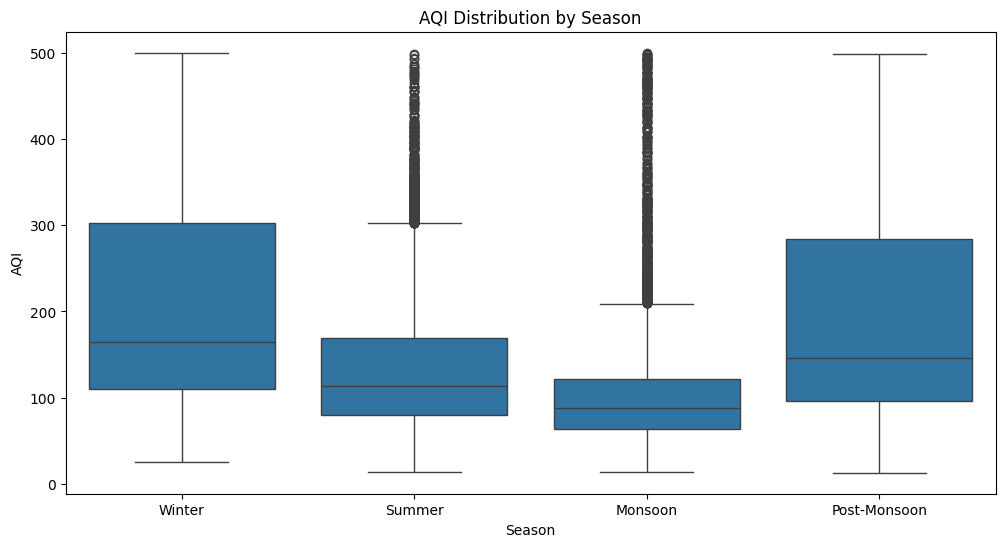

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Season',
    y='AQI'
)

plt.title('AQI Distribution by Season')

plt.show()

## COVID-19 Impact Assessment

The COVID-19 lockdown period significantly reduced transportation and industrial activity.

This section compares AQI levels before and during 2020 to evaluate the environmental impact of reduced human activity.

In [11]:
df['Period'] = np.where(
    df['Year']==2020,
    'COVID_2020',
    'Pre_COVID'
)

In [12]:
covid_analysis = (
    df.groupby('Period')['AQI']
      .mean()
      .reset_index()
)

covid_analysis

,Period,AQI
0,COVID_2020,110.934378
1,Pre_COVID,162.730443


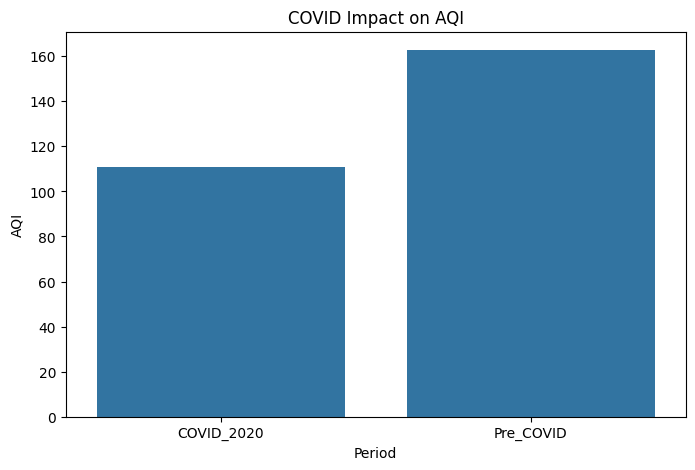

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=covid_analysis,
    x='Period',
    y='AQI'
)

plt.title('COVID Impact on AQI')

plt.show()

In [13]:
Pre_COVID = covid_analysis.iloc[1]["AQI"]
COVID_2020 = covid_analysis.iloc[0]["AQI"]

covid_change = ((COVID_2020 - Pre_COVID) / Pre_COVID) * 100

print(f"COVID period AQI was {abs(covid_change):.2f}% lower than the Pre-COVID average.")

COVID period AQI was 31.83% lower than the Pre-COVID average.


# Key Findings

1. Average AQI changed by -44.36% between 2015 and 2020.
2. The most polluted month was December.
3. The least polluted month was July.
4. The most polluted season was Winter.
5. COVID-19 resulted in a 31.83% change in AQI.
6. Strong seasonal patterns indicate recurring winter pollution spikes.